Экзамен

Дисциплина: Анализ данных и искусственный интеллект

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("finish.csv")
df.head()

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_per_flight,total_delay
0,2022,7,9E,ABE,33.0,2.0,0.92,1.00,0.08,0.0,...,0.0,0.0,129.0,98.0,23.0,8.0,0.0,0.0,3.794118,129.0
1,2022,7,9E,ABY,78.0,25.0,11.80,0.72,5.01,0.0,...,0.0,0.0,1664.0,887.0,52.0,224.0,0.0,501.0,21.063291,1664.0
2,2022,7,9E,ACK,124.0,19.0,5.84,1.00,6.76,0.0,...,5.0,4.0,1523.0,388.0,35.0,511.0,0.0,589.0,12.184000,1523.0
3,2022,7,9E,AEX,67.0,10.0,1.32,1.00,2.40,1.0,...,0.0,1.0,657.0,103.0,82.0,93.0,25.0,354.0,9.661765,632.0
4,2022,7,9E,AGS,174.0,30.0,18.10,5.75,3.60,0.0,...,1.0,0.0,2462.0,1686.0,310.0,139.0,0.0,327.0,14.068571,2462.0


In [13]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
year,88752.0,2019.546703,1.535892,2017.0,2018.00,2020.00,2021.00,2022.00
month,88752.0,6.287385,3.458985,1.0,3.00,6.00,9.00,12.00
arr_flights,88752.0,125.950086,170.915966,0.0,33.00,76.00,151.00,5322.00
arr_del15,88752.0,19.024890,21.248104,0.0,4.00,11.00,26.00,183.00
carrier_ct,88752.0,7.238747,8.735959,0.0,1.45,4.13,9.73,127.66
weather_ct,88752.0,0.796659,1.442031,0.0,0.00,0.00,1.00,28.00
nas_ct,88752.0,4.972413,7.195283,0.0,0.54,2.45,6.37,112.41
security_ct,88752.0,0.052979,0.303511,0.0,0.00,0.00,0.00,26.07
late_aircraft_ct,88752.0,5.964142,8.073994,0.0,0.80,2.98,7.99,86.39
arr_cancelled,88752.0,3.704345,32.555725,0.0,0.00,0.00,2.00,2839.00


Краткий анализ данных

In [15]:
df_work = df.sample(n=min(20000, len(df)), random_state=42)

y = df_work["arr_delay"]
X = df_work.drop(columns=["arr_delay"])

X = X.drop(columns=["total_delay"], errors="ignore")

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Подготовка данных

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

metrics = pd.DataFrame({
    "Метрика": ["MAE", "MSE", "R2"],
    "Значение": [
        mean_absolute_error(y_test, pred),
        mean_squared_error(y_test, pred),
        r2_score(y_test, pred)
    ]
})
metrics

,Метрика,Значение
0,MAE,0.036111
1,MSE,0.004627
2,R2,1.000000


Обучение модели Linear Regression

In [7]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(model.coef_)
}).sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
4,carrier_ct,15.207009
3,arr_del15,15.206737
6,nas_ct,15.206539
8,late_aircraft_ct,15.206398
5,weather_ct,15.206286
7,security_ct,15.204356
11,carrier_delay,1.000001
13,nas_delay,1.000000
15,late_aircraft_delay,0.999995
12,weather_delay,0.999995


Анализ важности признаков

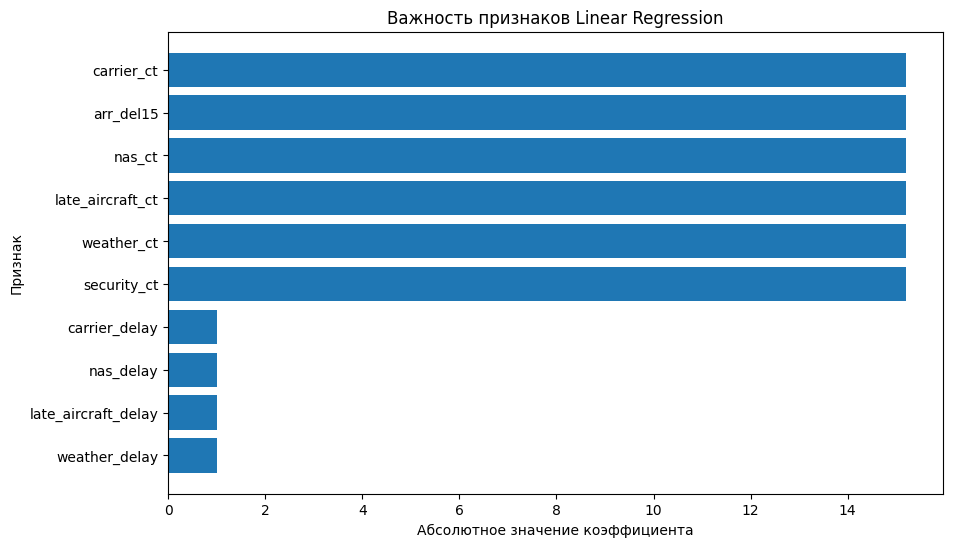

In [8]:
top = importance.head(10).sort_values("Importance")
plt.figure(figsize=(10, 6))
plt.barh(top["Feature"], top["Importance"])
plt.title("Важность признаков Linear Regression")
plt.xlabel("Абсолютное значение коэффициента")
plt.ylabel("Признак")
plt.show()

In [9]:
forest = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
3,arr_del15,0.845840
11,carrier_delay,0.055694
15,late_aircraft_delay,0.045050
16,delay_per_flight,0.018365
13,nas_delay,0.011934
12,weather_delay,0.010992
2,arr_flights,0.005062
6,nas_ct,0.001119
5,weather_ct,0.001011
8,late_aircraft_ct,0.000851


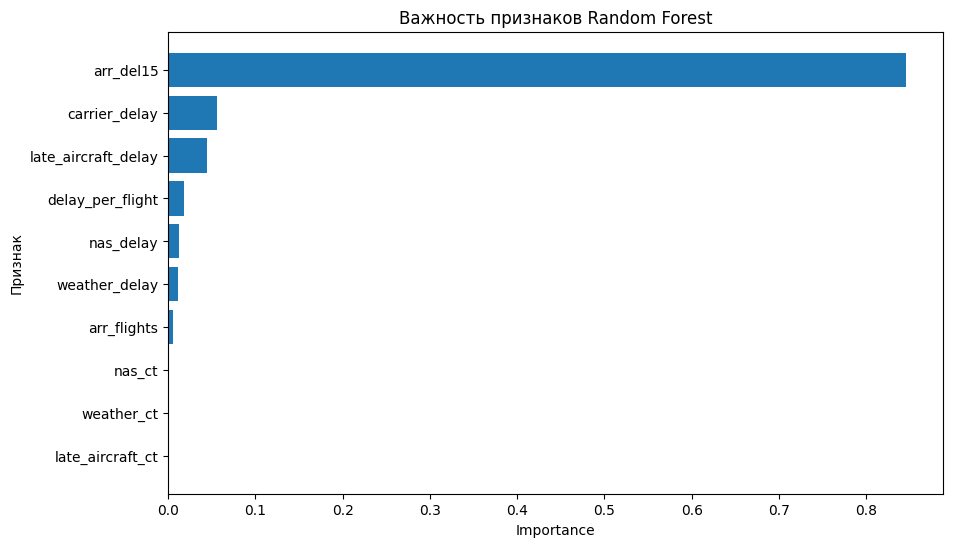

In [10]:
top_rf = rf_importance.head(10).sort_values("Importance")
plt.figure(figsize=(10, 6))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.title("Важность признаков Random Forest")
plt.xlabel("Importance")
plt.ylabel("Признак")
plt.show()

Дополнительная важность через Random Forest

In [11]:
errors = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})
errors["Error"] = abs(errors["Actual"] - errors["Predicted"])
errors.sort_values(by="Error", ascending=False).head(10)

,Actual,Predicted,Error
52834,3789.0,3789.203499,0.203499
49566,2908.0,2908.191047,0.191047
13959,495.0,495.189886,0.189886
50027,4996.0,4995.811871,0.188129
54134,728.0,728.187025,0.187025
15463,323.0,322.820227,0.179773
19910,1632.0,1632.179279,0.179279
36882,5581.0,5581.178006,0.178006
64354,361.0,361.177576,0.177576
81204,2512.0,2511.822865,0.177135


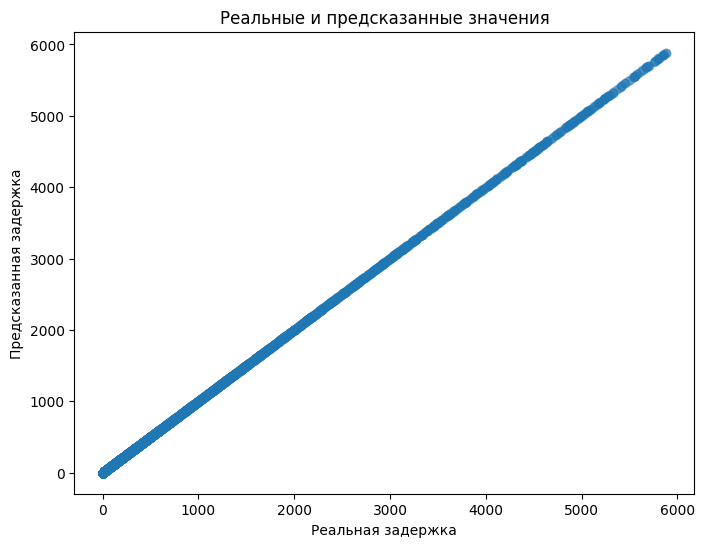

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.4)
plt.xlabel("Реальная задержка")
plt.ylabel("Предсказанная задержка")
plt.title("Реальные и предсказанные значения")
plt.show()

Анализ ошибок

Теоретические вопросы и ответы на них:

1 Что такое исследовательский анализ данных (EDA)?

EDA - это исследовательский анализ данных, который выполняется перед построением модели машинного обучения. Его цель понять структуру датасета, найти проблемы в данных и определить, какие признаки могут быть полезны для дальнейшего анализа. В данном проекте EDA применялся к данным о задержках авиарейсов, где изучались количество рейсов, задержки, отмены, причины задержек и итоговое время задержки.

Основные этапы EDA

К основным этапам EDA относятся загрузка датасета, просмотр первых строк, анализ размера таблицы, изучение типов данных, расчет описательной статистики, проверка пропусков, поиск выбросов, построение графиков распределений и анализ взаимосвязей между признаками. Для анализа пропусков используются команды df.isnull().sum() и визуализация пропусков. Выбросы можно искать с помощью boxplot, межквартильного размаха IQR и описательной статистики.

Роль Feature Engineering

Feature Engineering - это создание новых признаков на основе уже имеющихся данных. Такие признаки помогают модели лучше понимать данные и повышают качество прогнозирования.

2 Методы подготовки данных перед обучением модели

Перед обучением модели данные необходимо привести к удобному для алгоритма виду. На этом этапе выполняется обработка пропусков, удаление нерелевантных признаков, кодирование категориальных переменных, масштабирование числовых признаков и разделение данных на обучающую и тестовую выборки.

Кодирование категориальных признаков

Категориальные признаки, например carrier и airport, необходимо преобразовать в числовой формат. Для этого применяются Label Encoding и One-Hot Encoding. Label Encoding присваивает каждой категории числовой код, а One-Hot Encoding создает отдельный бинарный столбец для каждой категории. Для линейной регрессии чаще используется One-Hot Encoding, потому что он не создает ложного порядка между категориями.

Масштабирование и удаление признаков

Масштабирование используется для приведения числовых признаков к единому диапазону. Часто применяются StandardScaler и MinMaxScaler. Нерелевантные признаки удаляются, если они не помогают предсказанию, содержат слишком много пропусков, дублируют другие признаки или приводят к утечке целевой переменной.

3 Переобучение модели и повышение качества

Переобучение (overfitting) - это ситуация, когда модель слишком хорошо запоминает обучающие данные, но плохо работает на новых данных. Обычно это видно по большой разнице между качеством на обучающей и тестовой выборках. Для борьбы с переобучением используют разделение данных на train/test, кросс-валидацию, регуляризацию, упрощение модели, удаление лишних признаков и подбор гиперпараметров.

GridSearch и сравнение моделей

GridSearchCV используется для автоматического подбора гиперпараметров. Он перебирает разные комбинации параметров, обучает модель с кросс-валидацией и выбирает лучший вариант. В лабораторных работах сравнивались Linear Regression, Decision Tree Regressor и Random Forest Regressor. Лучшая модель выбирается по метрикам качества и по устойчивости на тестовой выборке.

Вывод:
Была построена модель для прогнозирования задержки авиарейсов. Данные были подготовлены, категориальные признаки закодированы, выборка разделена на обучающую и тестовую. Метрики качества позволяют оценить точность модели, а анализ важности признаков показывает, какие факторы сильнее всего влияют на прогноз. Практическое применение модели — предварительный прогноз задержек, улучшение расписания и повышение качества обслуживания пассажиров.